In [1]:
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching as pm

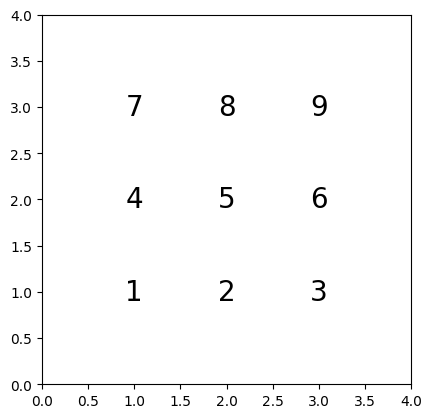

In [2]:
x_positions = [1, 2, 3, 1, 2, 3, 1, 2, 3]
y_positions = [1, 1, 1, 2, 2, 2, 3, 3, 3]

for i in range(9):
    plt.text(x_positions[i], y_positions[i], f'{i + 1}', ha='center', va='center', fontsize=20)

plt.xlim(0, 4)
plt.ylim(0, 4)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()


In [6]:
import stim
import pymatching as pm

def build_bacon_shor_3x3_circuit_stim(
    p,
    rounds=5,
    error_gate='X',        # 'X' or 'Z' like your Shor version
    readout='Z',           # 'Z' => logical Z, 'X' => logical X
):
    """
    3x3 Bacon–Shor [[9,1,3]] skeleton:
      - prepare data (simple |0...0> start; you can swap in a better prep later)
      - for each round:
          apply data noise
          measure all ZZ gauges, then all XX gauges
          create detectors on stabilizer parities (as differences across rounds)
      - final logical readout + OBSERVABLE_INCLUDE(0)
    """
    data = list(range(9))

    # Gauge edge lists (order matters because we reference measurement indices)
    zz_edges = [(0,3),(1,4),(2,5),(3,6),(4,7),(5,8)]   # 6 results
    xx_edges = [(0,1),(1,2),(3,4),(4,5),(6,7),(7,8)]   # 6 results

    # Stabilizers as triples of gauge indices within each set
    # Indices refer to positions in zz_edges / xx_edges
    z_stabs = [
        (0,1,2),  # (0,3)(1,4)(2,5)
        (3,4,5),  # (3,6)(4,7)(5,8)
    ]
    x_stabs = [
        (0,2,4),  # (0,1)(3,4)(6,7)
        (1,3,5),  # (1,2)(4,5)(7,8)
    ]

    lines = []

    # --- (A) Initialize data ---
    # This is a *simple* start state; for logical benchmarking you often
    # want a dedicated prep routine. But this keeps structure clear.
    lines.append("R " + " ".join(map(str, data)))

    # helper: convert absolute measurement index -> stim rec[-k]
    meas_count = 0
    def rec_of(abs_meas_index: int) -> str:
        # abs_meas_index counts from 0; stim uses rec[-1] = most recent
        k = meas_count - abs_meas_index
        return f"rec[-{k}]"

    prev_zz_abs = None  # list of 6 abs indices
    prev_xx_abs = None  # list of 6 abs indices

    # --- (B) Syndrome rounds ---
    for t in range(rounds):
        # Data noise (your style: apply only X or only Z)
        if error_gate == 'X':
            lines.append(f"X_ERROR({p}) " + " ".join(map(str, data)))
        elif error_gate == 'Z':
            lines.append(f"Z_ERROR({p}) " + " ".join(map(str, data)))
        else:
            raise ValueError("error_gate must be 'X' or 'Z'")

        # Measure ZZ gauges (6 measurements)
        zz_abs = []
        for a,b in zz_edges:
            lines.append(f"MZZ {a} {b}")
            zz_abs.append(meas_count)
            meas_count += 1

        # Measure XX gauges (6 measurements)
        xx_abs = []
        for a,b in xx_edges:
            lines.append(f"MXX {a} {b}")
            xx_abs.append(meas_count)
            meas_count += 1

        # Detectors:
        # Use stabilizer parity *differences across rounds*.
        #
        # Round 0: anchor to initial (+1) by using just current parity.
        # Later rounds: parity(t) ⊕ parity(t-1).
        #
        # Z stabilizers (from ZZ gauges)
        for (i,j,k) in z_stabs:
            if prev_zz_abs is None:
                lines.append(
                    "DETECTOR " +
                    " ".join([rec_of(zz_abs[i]), rec_of(zz_abs[j]), rec_of(zz_abs[k])])
                )
            else:
                lines.append(
                    "DETECTOR " +
                    " ".join([
                        rec_of(zz_abs[i]), rec_of(zz_abs[j]), rec_of(zz_abs[k]),
                        rec_of(prev_zz_abs[i]), rec_of(prev_zz_abs[j]), rec_of(prev_zz_abs[k]),
                    ])
                )

        # X stabilizers (from XX gauges)
        for (i,j,k) in x_stabs:
            if prev_xx_abs is None:
                lines.append(
                    "DETECTOR " +
                    " ".join([rec_of(xx_abs[i]), rec_of(xx_abs[j]), rec_of(xx_abs[k])])
                )
            else:
                lines.append(
                    "DETECTOR " +
                    " ".join([
                        rec_of(xx_abs[i]), rec_of(xx_abs[j]), rec_of(xx_abs[k]),
                        rec_of(prev_xx_abs[i]), rec_of(prev_xx_abs[j]), rec_of(prev_xx_abs[k]),
                    ])
                )

        prev_zz_abs = zz_abs
        prev_xx_abs = xx_abs

    # --- (C) Final logical readout + observable ---
    # Pick one standard representative (others differ by gauge).
    if readout == 'Z':
        # Measure Z on a full column, e.g. (0,3,6)
        lines.append("M 0 3 6")
        # Observable = product parity of these 3 measurements
        lines.append("OBSERVABLE_INCLUDE(0) rec[-3] rec[-2] rec[-1]")
    elif readout == 'X':
        # Measure X on a full row, e.g. (0,1,2)
        lines.append("MX 0 1 2")
        lines.append("OBSERVABLE_INCLUDE(0) rec[-3] rec[-2] rec[-1]")
    else:
        raise ValueError("readout must be 'Z' or 'X'")

    return stim.Circuit("\n".join(lines))


def get_logical_error_probability_for_bacon_shor(
    p, rounds=5, n_shots=50_000, error_gate='X', readout='Z', verbose=False
):
    circuit = build_bacon_shor_3x3_circuit_stim(
        p=p, rounds=rounds, error_gate=error_gate, readout=readout
    )
    if verbose:
        display(circuit.diagram('timeline-svg'))

    ds = circuit.compile_detector_sampler()
    D, L = ds.sample(n_shots, separate_observables=True)

    dem = circuit.detector_error_model(decompose_errors=True)
    m = pm.Matching.from_detector_error_model(dem)

    pred = m.decode_batch(D)
    return (pred[:, 0] != L[:, 0]).mean()

def get_logical_error_probability_for_bacon_shor_stim(ps, n_shots=50_000, error_gate='X'):
    p_Ls = []
    for j, p in enumerate(ps):
        if j == 0:
            p_Ls.append(get_logical_error_probability_for_bacon_shor(p, n_shots=n_shots, error_gate=error_gate, verbose = True))
        else:
            p_Ls.append(get_logical_error_probability_for_bacon_shor(p, n_shots=n_shots, error_gate=error_gate, verbose = False))          
    return p_Ls


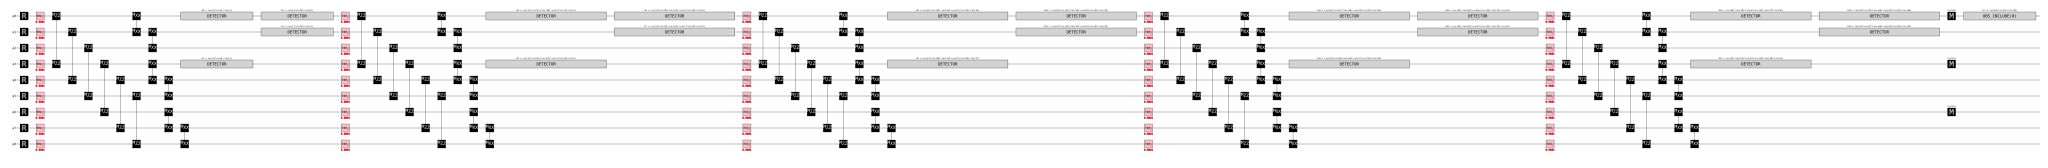

ValueError: The circuit contains non-deterministic observables.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['L0', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords L0 > output_image.svg

This was discovered while analyzing an X-basis pair measurement (MXX) on:
    qubit 7

The collapse anti-commuted with these detectors/observables:
    L0

The backward-propagating error sensitivity for L0 was:
    Z0
    Z3
    Z6
    Z7

Circuit stack trace:
    at instruction #32 [which is MXX 0 1 1 2 3 4 4 5 6 7 7 8]

In [7]:
ps = np.logspace(-4, -0.5, 20)
n_shots = 1000000

p_Ls = get_logical_error_probability_for_bacon_shor_stim(ps = ps, n_shots = n_shots, error_gate = 'Z')

plt.plot(ps, p_Ls, 'o', color = 'black')
plt.plot([0, 1], [0, 1], color = 'black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical error rate')
plt.ylabel('Logical error rate')
plt.title('Logical error rate vs physical error rate for Shor code')
plt.show()